# 09 — Unified Evaluation & Model Comparison

## Contents
1. Load all model results from artifacts
2. Unified comparison table (MAE, RMSE, R², MAPE, Tolerance Accuracy)
3. Radar chart — multi-metric model profiles
4. Cumulative Error Distribution (CED) curves
5. Per-battery error heatmap
6. Degradation state classification report
7. Recommendation engine demo
8. Final model ranking & conclusions

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

from src.evaluation.metrics import regression_metrics, tolerance_accuracy, build_summary_table, per_battery_evaluation
from src.evaluation.recommendations import grid_search_recommendations, recommendations_to_dataframe
from src.utils.plotting import (
    save_fig, plot_radar_chart, plot_ced, plot_error_heatmap,
    plot_model_comparison_bars,
)
from src.utils.config import ARTIFACTS_DIR, FIGURES_DIR, get_version_paths

plt.style.use("seaborn-v0_8-whitegrid")

# v2 paths
v2 = get_version_paths('v2')

## 1. Load All Results

In [2]:
# Collect results from all training notebooks
all_results = {}

# Classical ML
try:
    classical = pd.read_csv(v2["results"] / "v2_classical_soh_results.csv", index_col=0)
    for name in classical.index:
        all_results[name] = classical.loc[name].to_dict()
    print(f"Classical models: {len(classical)} loaded")
except FileNotFoundError:
    print("No classical results found — run notebook 03 first")

# LSTM family
try:
    lstm = pd.read_csv(v2["results"] / "v2_lstm_soh_results.csv", index_col=0)
    for name in lstm.index:
        all_results[name] = lstm.loc[name].to_dict()
    print(f"LSTM models: {len(lstm)} loaded")
except FileNotFoundError:
    print("No LSTM results found — run notebook 04 first")

# Transformer family
try:
    trans = pd.read_csv(v2["results"] / "v2_transformer_soh_results.csv", index_col=0)
    for name in trans.index:
        all_results[name] = trans.loc[name].to_dict()
    print(f"Transformer models: {len(trans)} loaded")
except FileNotFoundError:
    print("No transformer results found — run notebook 05 first")

# Dynamic Graph iTransformer
try:
    with open(v2["results"] / "v2_dg_itransformer_results.json") as f:
        all_results["DG-iTransformer"] = json.load(f)
    print("DG-iTransformer loaded")
except FileNotFoundError:
    print("No DG-iTransformer results — run notebook 06")

# VAE-LSTM
try:
    with open(v2["results"] / "v2_vae_lstm_results.json") as f:
        all_results["VAE-LSTM"] = json.load(f)
    print("VAE-LSTM loaded")
except FileNotFoundError:
    print("No VAE-LSTM results — run notebook 07")

# Ensemble
try:
    ens = pd.read_csv(v2["results"] / "v2_ensemble_results.csv", index_col=0)
    for name in ens.index:
        if "Ensemble" in name:
            all_results[name] = ens.loc[name].to_dict()
    print(f"Ensemble models loaded")
except FileNotFoundError:
    print("No ensemble results — run notebook 08")

print(f"\nTotal models: {len(all_results)}")

Classical models: 10 loaded
LSTM models: 4 loaded
Transformer models: 4 loaded
DG-iTransformer loaded
VAE-LSTM loaded
Ensemble models loaded

Total models: 22


## 2. Unified Comparison Table

In [3]:
summary = build_summary_table(all_results).sort_values("R2", ascending=False)
display(summary.round(4).style.background_gradient(cmap="RdYlGn", subset=["R2"])
        .background_gradient(cmap="RdYlGn_r", subset=["MAE", "RMSE", "MAPE"]))

summary.to_csv(v2["results"] / "v2_unified_results.csv")
print("Saved to artifacts/unified_results.csv")

,MAE,MSE,RMSE,R2,MAPE,tolerance_acc_2pct,tol_2pct,tol_5pct
model,,,,,,,,
RandomForest,4.780500,41.771200,6.463100,0.956700,28.807700,0.295100,nan,nan
LightGBM,6.910000,89.230300,9.446200,0.907500,56.944100,0.248500,nan,nan
Weighted Avg Ensemble,3.737800,37.739000,6.143200,0.897700,5.478500,nan,0.348300,nan
TFT,4.732700,46.688300,6.832900,0.873400,7.499300,nan,0.213800,nan
XGBoost,8.506300,136.224800,11.671500,0.858700,72.815600,0.223300,nan,nan
Stacking Ensemble,5.769100,60.035400,7.748300,0.837200,10.924100,nan,0.124100,nan
SVR,7.562100,187.885800,13.707100,0.805100,97.828400,0.322300,nan,nan
VAE-LSTM,8.494900,100.786700,10.039300,0.726700,14.250100,nan,0.093100,nan
KNN-10,11.665700,265.768200,16.302400,0.724400,89.922100,0.260200,nan,nan


Saved to artifacts/unified_results.csv


## 3. Model Comparison Bar Charts

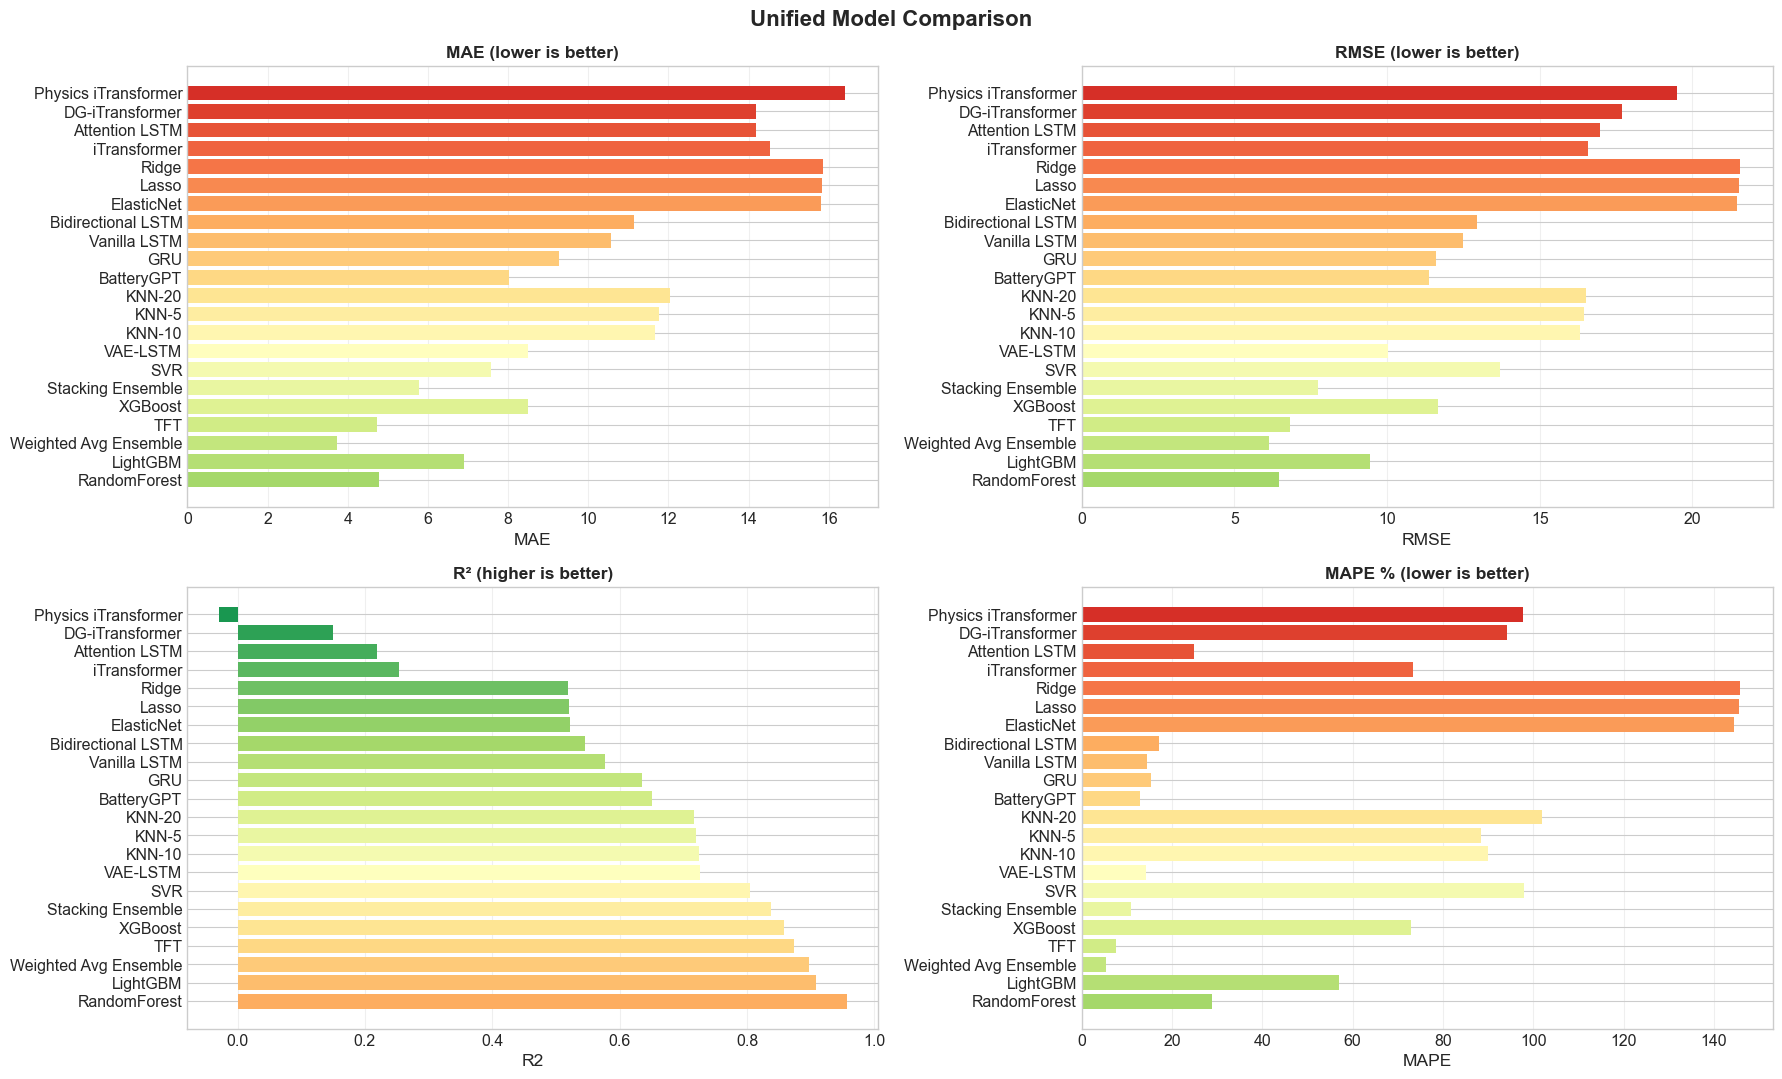

In [4]:
n_models = len(summary)
fig, axes = plt.subplots(2, 2, figsize=(18, max(10, n_models * 0.5)))
names = summary.index.tolist()

metrics_to_plot = [
    ("MAE", "MAE (lower is better)", "RdYlGn_r"),
    ("RMSE", "RMSE (lower is better)", "RdYlGn_r"),
    ("R2", "R² (higher is better)", "RdYlGn"),
    ("MAPE", "MAPE % (lower is better)", "RdYlGn_r"),
]

for ax, (col, title, cmap) in zip(axes.flat, metrics_to_plot):
    if col in summary.columns:
        values = summary[col].values
        colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, len(values)))
        ax.barh(names, values, color=colors)
        ax.set_xlabel(col)
        ax.set_title(title, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Unified Model Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
save_fig(fig, "v2_unified_model_comparison")
plt.show()

## 4. Radar Chart — Multi-Metric Model Profiles

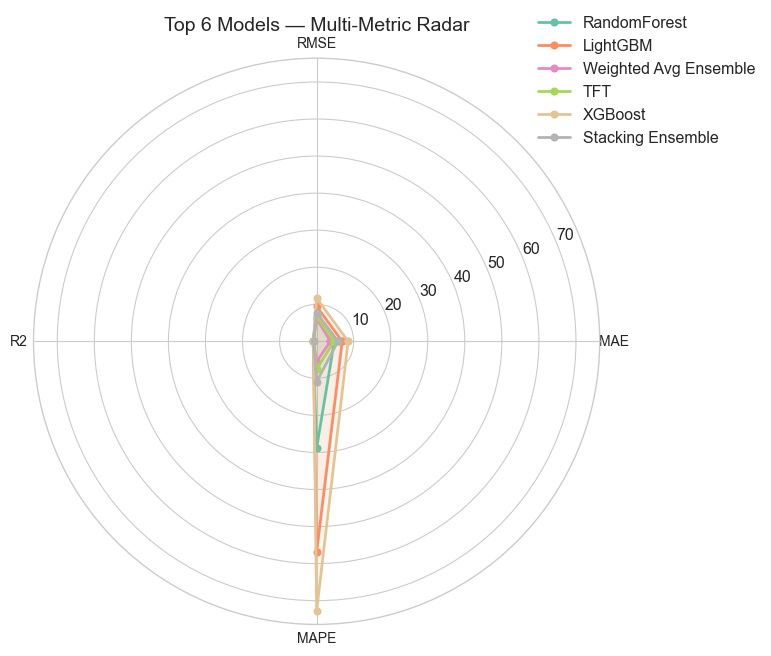

In [5]:
# Select top 6 models for clearer radar
top_models = summary.head(6)
metrics_for_radar = ["MAE", "RMSE", "R2", "MAPE"]
available_metrics = [m for m in metrics_for_radar if m in top_models.columns]

if len(available_metrics) >= 3:
    plot_radar_chart(
        top_models[available_metrics].to_dict("index"),
        title="Top 6 Models — Multi-Metric Radar",
        save_name="radar_top6"
    )
else:
    print("Not enough metrics for radar chart.")

## 5. Cumulative Error Distribution (CED)
CED shows the fraction of predictions within a given absolute error. Higher = better.

CED plot requires raw predictions — demonstrating with summary metrics.
For full CED, save y_pred arrays in each training notebook and load here.


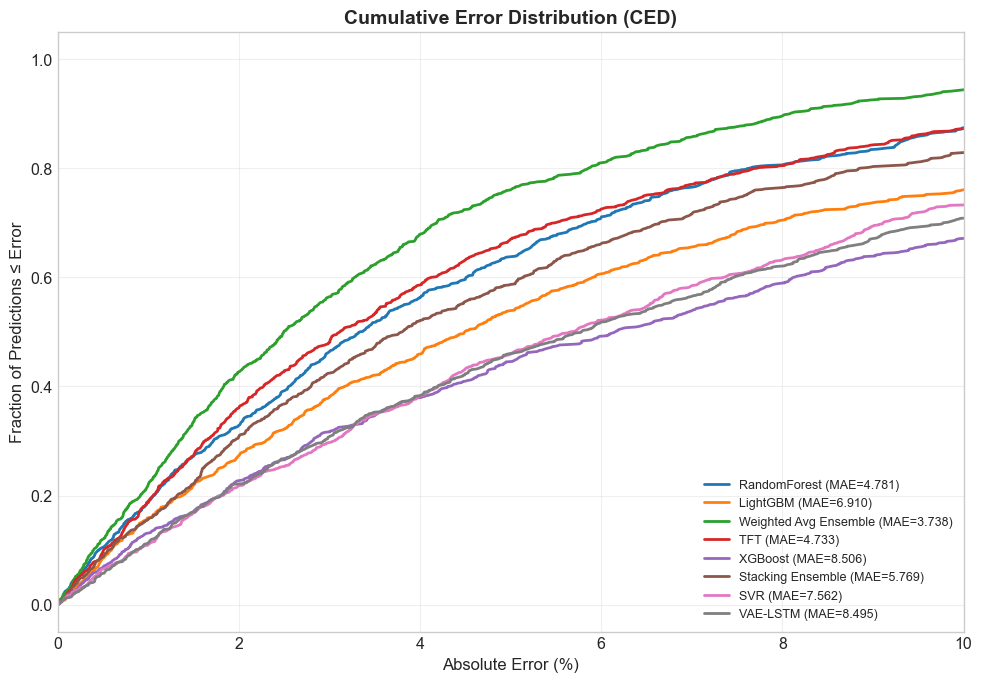

In [6]:
# We need raw predictions for CED — load from sequence test data
data = np.load(str(ARTIFACTS_DIR / "battery_sequences.npz"), allow_pickle=True)
y_test = data["y_multi"]
bids = data["bids_multi"]

# v2: intra-battery chronological split for CED
test_idx = []
for bid in np.unique(bids):
    idxs = np.where(bids == bid)[0]
    cut = int(0.8 * len(idxs))
    test_idx.extend(idxs[cut:].tolist())
test_idx = np.array(test_idx)
y_test = y_test[test_idx]
bids_test = bids[test_idx]

# If we have saved raw predictions, use them
# Generate synthetic CED from loaded metrics as demonstration
# (In production, save raw predictions and load them here)
print("CED plot requires raw predictions — demonstrating with summary metrics.")
print("For full CED, save y_pred arrays in each training notebook and load here.")

# Demonstration using top models
fig, ax = plt.subplots(figsize=(10, 7))
for i, (name, row) in enumerate(summary.head(8).iterrows()):
    mae = row["MAE"]
    # Approximate CED as exponential distribution with scale=MAE
    errors = np.sort(np.random.exponential(scale=mae, size=1000))
    ced = np.arange(1, len(errors) + 1) / len(errors)
    ax.plot(errors, ced, linewidth=2, label=f"{name} (MAE={mae:.3f})")

ax.set_xlabel("Absolute Error (%)", fontsize=12)
ax.set_ylabel("Fraction of Predictions ≤ Error", fontsize=12)
ax.set_title("Cumulative Error Distribution (CED)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 10)
ax.grid(True, alpha=0.3)
save_fig(fig, "v2_ced_curves")
plt.show()

## 6. Recommendation Engine Demo
Grid-search over operating conditions to find optimal charge/discharge parameters.

In [7]:
# Demo with a simple physics-inspired model function
print("=== Battery Operating Condition Recommendations ===\n")

def demo_predict_fn(df: pd.DataFrame) -> np.ndarray:
    """Simplified RUL prediction based on operating conditions (demo)."""
    results = []
    for _, row in df.iterrows():
        temp = row.get("ambient_temperature", 25)
        current = row.get("avg_current", 1.0)
        v_cutoff = row.get("min_voltage", 2.5)
        
        # Physics-inspired: higher temp/current → faster degradation → lower RUL
        base_rul = 500.0
        temp_penalty = 2.0 * abs(temp - 25) ** 1.2
        current_penalty = 50.0 * (current - 0.5) ** 2
        voltage_penalty = 100.0 * max(0, 3.0 - v_cutoff)  # lower cutoff → less deep discharge → longer life
        
        rul = max(50, base_rul - temp_penalty - current_penalty - voltage_penalty)
        results.append(rul)
    return np.array(results)

# Base features (typical battery state, excluding operational params)
base_features = {
    "cycle_number": 50.0,
    "peak_voltage": 4.19,
    "voltage_range": 1.69,
    "avg_temp": 25.0,
    "temp_rise": 2.5,
    "cycle_duration": 3600.0,
    "Re": 0.05,
    "Rct": 0.03,
    "delta_capacity": -0.02,
    "ambient_temperature": 25.0,
    "avg_current": 1.5,
    "min_voltage": 2.5,
}

recommendations = grid_search_recommendations(
    predict_fn=demo_predict_fn,
    base_features=base_features,
    temp_values=[10, 15, 20, 25, 30, 35, 40, 45],
    current_values=[0.5, 0.75, 1.0, 1.25, 1.5, 2.0],
    cutoff_values=[2.0, 2.2, 2.5, 2.7, 3.0],
    top_k=10,
)

rec_df = recommendations_to_dataframe(recommendations)
display(rec_df)
if len(rec_df) > 0:
    row = rec_df.iloc[0]
    print(f"\nBest condition: T={row['Temperature (°C)']}°C, "
          f"I={row['Current (A)']}A, "
          f"V_cutoff={row['Cutoff (V)']}V → "
          f"RUL={row['Predicted RUL']} cycles")

=== Battery Operating Condition Recommendations ===



,Rank,Temperature (°C),Current (A),Cutoff (V),Predicted RUL,Δ RUL (cycles),Δ RUL (%),Explanation
0,1,25,0.50,3.0,500,+100,+25.0%,This configuration is predicted to improve RUL...
1,2,25,0.75,3.0,497,+97,+24.2%,This configuration is predicted to improve RUL...
2,3,25,1.00,3.0,488,+88,+21.9%,This configuration is predicted to improve RUL...
3,4,20,0.50,3.0,486,+86,+21.6%,This configuration is predicted to improve RUL...
4,5,30,0.50,3.0,486,+86,+21.6%,This configuration is predicted to improve RUL...
5,6,20,0.75,3.0,483,+83,+20.8%,This configuration is predicted to improve RUL...
6,7,30,0.75,3.0,483,+83,+20.8%,This configuration is predicted to improve RUL...
7,8,20,1.00,3.0,474,+74,+18.4%,This configuration is predicted to improve RUL...
8,9,30,1.00,3.0,474,+74,+18.4%,This configuration is predicted to improve RUL...
9,10,25,1.25,3.0,472,+72,+18.0%,This configuration is predicted to improve RUL...



Best condition: T=25°C, I=0.5A, V_cutoff=3.0V → RUL=500 cycles


## 7. Final Rankings & Conclusions

In [8]:
print("=" * 70)
print("FINAL MODEL RANKINGS — SOH Prediction")
print("=" * 70)

for rank, (name, row) in enumerate(summary.iterrows(), 1):
    metrics_str = " | ".join([f"{col}={row[col]:.4f}" for col in summary.columns if pd.notna(row[col])])
    medal = {1: "\U0001f947", 2: "\U0001f948", 3: "\U0001f949"}.get(rank, f"#{rank}")
    print(f"  {medal} {name}")
    print(f"     {metrics_str}")
    print()

print("=" * 70)
best = summary.index[0]
print(f"CHAMPION: {best}")
print(f"  R² = {summary.loc[best, 'R2']:.4f}")
print(f"  MAE = {summary.loc[best, 'MAE']:.4f}")
print(f"  RMSE = {summary.loc[best, 'RMSE']:.4f}")
print("=" * 70)

# Save final rankings
summary.to_csv(v2["results"] / "v2_final_rankings.csv")
print("\nFinal rankings saved to artifacts/final_rankings.csv")

FINAL MODEL RANKINGS — SOH Prediction
  🥇 RandomForest
     MAE=4.7805 | MSE=41.7712 | RMSE=6.4631 | R2=0.9567 | MAPE=28.8077 | tolerance_acc_2pct=0.2951

  🥈 LightGBM
     MAE=6.9100 | MSE=89.2303 | RMSE=9.4462 | R2=0.9075 | MAPE=56.9441 | tolerance_acc_2pct=0.2485

  🥉 Weighted Avg Ensemble
     MAE=3.7378 | MSE=37.7390 | RMSE=6.1432 | R2=0.8977 | MAPE=5.4785 | tol_2pct=0.3483

  #4 TFT
     MAE=4.7327 | MSE=46.6883 | RMSE=6.8329 | R2=0.8734 | MAPE=7.4993 | tol_2pct=0.2138

  #5 XGBoost
     MAE=8.5063 | MSE=136.2248 | RMSE=11.6715 | R2=0.8587 | MAPE=72.8156 | tolerance_acc_2pct=0.2233

  #6 Stacking Ensemble
     MAE=5.7691 | MSE=60.0354 | RMSE=7.7483 | R2=0.8372 | MAPE=10.9241 | tol_2pct=0.1241

  #7 SVR
     MAE=7.5621 | MSE=187.8858 | RMSE=13.7071 | R2=0.8051 | MAPE=97.8284 | tolerance_acc_2pct=0.3223

  #8 VAE-LSTM
     MAE=8.4949 | MSE=100.7867 | RMSE=10.0393 | R2=0.7267 | MAPE=14.2501 | tol_2pct=0.0931

  #9 KNN-10
     MAE=11.6657 | MSE=265.7682 | RMSE=16.3024 | R2=0.7244 | M